# 5. P&L Tracking (2026 Portfolio, Live)

Live forward P&L for the **2026 portfolio** with rebalancing trades executed
on **12-Apr-2026** via InvestEngine + Trading212. Unlike the backtest in
[`04_backtesting.ipynb`](04_backtesting.ipynb), this notebook is designed to
re-run regularly: it picks up new trades from the InvestEngine statement
(parsed and persisted to the SQLite DB) and extends the rolling P&L curve
through today.

UK financial-year window: **05-Apr-2026 → today**.


In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("..").resolve()))

from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from etf_utils.config import RISK_FREE_RATE, PROJECT_ROOT
from etf_utils.data_provider import DataProvider
from etf_utils.database import (
    load_portfolio,
    save_rebalancing_trades,
    load_rebalancing_trades,
)
from etf_utils.backtesting import (
    Backtester,
    parse_investengine_statement,
)
from etf_utils.metrics import (
    calculate_beta,
    calculate_information_ratio,
    calculate_max_drawdown,
    calculate_sharpe_ratio,
    calculate_tracking_error,
    rolling_volatility_from_cumret,
)

FY26_START = pd.Timestamp("2026-04-05")
TODAY      = pd.Timestamp.now().normalize()
FY26_BDAYS = len(pd.bdate_range(FY26_START, TODAY))

provider = DataProvider()
portfolio_26 = load_portfolio(year=2026)
print(f"Loaded 2026 portfolio: {len(portfolio_26)} positions, "
      f"{portfolio_26['asset_class'].nunique()} asset classes.")
print(f"Tracking window: {FY26_START.date()} → {TODAY.date()} "
      f"({FY26_BDAYS} business days).")


Loaded 2026 portfolio: 20 positions, 4 asset classes.
Tracking window: 2026-04-05 → 2026-04-18 (10 business days).


## 0. Data Quality Check (2026 Portfolio)


In [2]:
tickers_26 = sorted(portfolio_26['ticker'].unique().tolist())

_price_data = {}
_fetch_errors = []
for t in tickers_26:
    try:
        _price_data[t] = provider.get_historical_prices(t)
    except Exception as exc:
        _fetch_errors.append((t, str(exc)))

rows = []
for t in tickers_26:
    if t not in _price_data or 'close' not in _price_data[t].columns:
        rows.append({'Ticker': t, 'First Date': None, 'Last Date': None,
                     'Trading Days': 0, 'Missing Days': FY26_BDAYS,
                     'Gap %': 100.0, 'Last Price': None, 'Stale': True})
        continue
    close = _price_data[t]['close'].dropna()
    if close.empty:
        rows.append({'Ticker': t, 'First Date': None, 'Last Date': None,
                     'Trading Days': 0, 'Missing Days': FY26_BDAYS,
                     'Gap %': 100.0, 'Last Price': None, 'Stale': True})
        continue
    close_fy = close.loc[FY26_START:TODAY]
    actual = len(close_fy)
    missing = FY26_BDAYS - actual
    gap_pct = missing / FY26_BDAYS * 100 if FY26_BDAYS > 0 else 0
    last = close.index.max()
    rows.append({
        'Ticker': t,
        'First Date': close.index.min().date(),
        'Last Date': last.date(),
        'Trading Days': actual,
        'Missing Days': missing,
        'Gap %': gap_pct,
        'Last Price': close.iloc[-1],
        'Stale': (TODAY - last).days > 5,
    })

quality_df = pd.DataFrame(rows).set_index('Ticker')

def _flag_gaps(val):
    if pd.isna(val): return ''
    if val > 5: return 'color: #dc2626; font-weight: bold'
    if val > 1: return 'color: #f97316'
    return 'color: #16a34a'

def _flag_stale(val):
    return 'background-color: #fef2f2; color: #dc2626; font-weight: bold' if val else ''

styled = (quality_df.style
    .format({
        'Trading Days': '{:.0f}',
        'Missing Days': lambda v: f'{v:.0f}' if pd.notna(v) else '-',
        'Gap %': lambda v: f'{v:.1f}%' if pd.notna(v) else '-',
        'Last Price': lambda v: f'£{v:.2f}' if pd.notna(v) else '-',
    })
    .map(_flag_gaps, subset=['Gap %'])
    .map(_flag_stale, subset=['Stale'])
    .set_caption(f'2026 Portfolio Data Quality — '
                 f'{FY26_START.date()} to {TODAY.date()} ({FY26_BDAYS} bdays)'))
display(styled)

print(f'Tickers: {len(tickers_26)} total, {len(_price_data)} fetched.')
for t, err in _fetch_errors:
    print(f'  FETCH ERROR: {t} — {err}')

# Reuse the fetched prices downstream
price_data_26 = _price_data
del _fetch_errors


C:\Users\rakes\AppData\Local\Temp\ipykernel_43784\3448676788.py:7: UserWarning: Ticker 'AIGA' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  _price_data[t] = provider.get_historical_prices(t)


C:\Users\rakes\AppData\Local\Temp\ipykernel_43784\3448676788.py:7: UserWarning: Ticker 'COPA' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  _price_data[t] = provider.get_historical_prices(t)


C:\Users\rakes\AppData\Local\Temp\ipykernel_43784\3448676788.py:7: UserWarning: Ticker 'RMAP' for provider 'alphavantage' not found in currency_units.json. Falling back to heuristic pence detection. 
  _price_data[t] = provider.get_historical_prices(t)


,First Date,Last Date,Trading Days,Missing Days,Gap %,Last Price,Stale
Ticker,,,,,,,
AIGA,2006-09-27,2026-04-17,9,1,10.0%,£6.17,False
AIGE,2006-09-27,2026-04-17,9,1,10.0%,£4.55,False
COPA,2007-03-16,2026-04-17,9,1,10.0%,£53.23,False
EMCP,2012-04-19,2026-04-17,9,1,10.0%,£66.86,False
HKOR,2011-04-07,2026-04-17,9,1,10.0%,£95.00,False
HMCH,2011-01-28,2026-04-17,9,1,10.0%,£6.04,False
IBZL,2005-11-21,2026-04-17,9,1,10.0%,£24.67,False
IGLT,2006-12-04,2026-04-17,9,1,10.0%,£9.88,False
IMIB,2007-07-12,2026-04-17,9,1,10.0%,£25.80,False


Tickers: 20 total, 20 fetched.


## 1. 2026 Trade Loading (InvestEngine Statement)

Parses `RebalancingTrades2026.csv` if present (and persists to the DB),
otherwise falls back to whatever's already in the DB. If neither exists, the
notebook shows an empty-portfolio summary so it remains runnable until the
first 2026 statement lands.


In [3]:
statement_path = (
    PROJECT_ROOT / "data" / "investment_statements" / "RebalancingTrades2026.csv"
)

if statement_path.exists():
    trades = parse_investengine_statement(statement_path)
    save_rebalancing_trades(trades, portfolio_year=2026)
    print(f"Parsed {len(trades)} trades from CSV and saved to DB.")
else:
    trades = load_rebalancing_trades(portfolio_year=2026)
    if trades.empty:
        print(f"No 2026 trades available yet "
              f"(no CSV at {statement_path} and DB is empty for year 2026).")
        print("Downstream cells will be skipped — re-run after the first "
              "rebalance statement lands.")
    else:
        trades["trade_date"] = pd.to_datetime(trades["trade_date"])
        print(f"Loaded {len(trades)} trades from DB.")

has_trades = not trades.empty
if has_trades:
    print(f"Date range: {trades['trade_date'].min().date()} → "
          f"{trades['trade_date'].max().date()}")
    print(f"Tickers: {trades['ticker'].nunique()}")


Parsed 64 trades from CSV and saved to DB.
Date range: 2026-03-23 → 2026-04-14
Tickers: 22


## 2. Backtester Setup & Daily P&L Curve


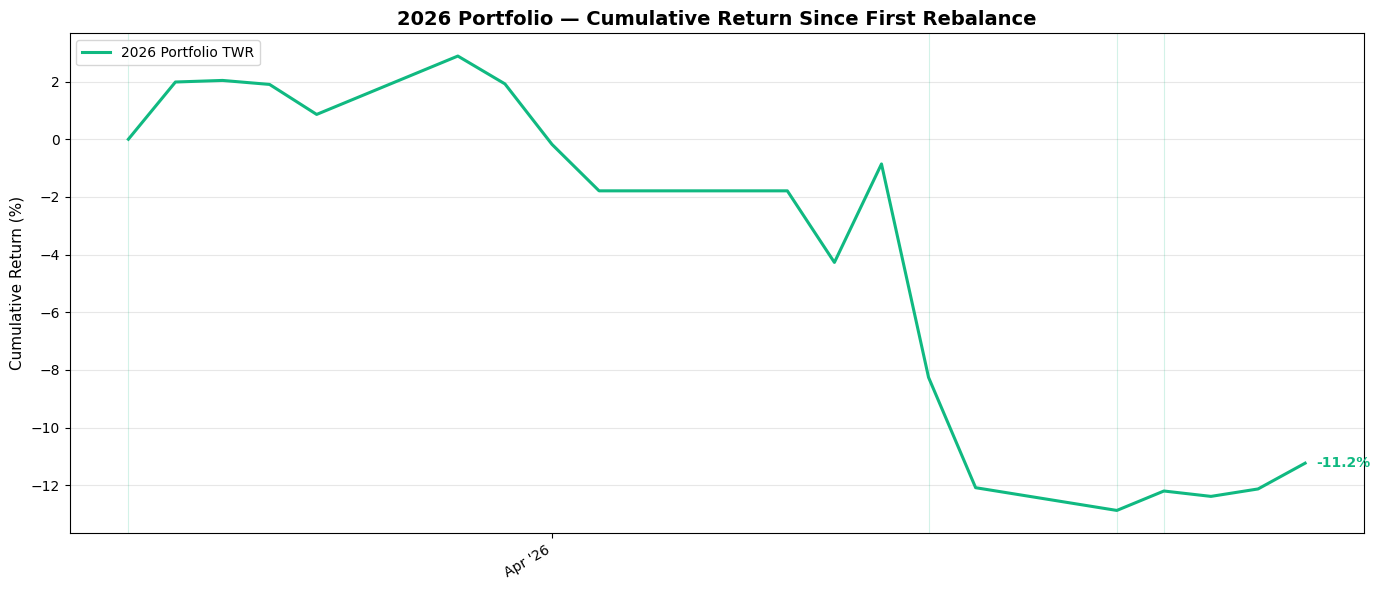


Current TWR: -11.23%


In [4]:
if has_trades:
    bt = Backtester.from_trades(trades, provider, end_date=TODAY)
    twr_series = bt.run_twr_series(trades)
    total_twr = twr_series.iloc[-1]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.plot(bt.all_dates, twr_series, color='#10b981', linewidth=2.2,
            label='2026 Portfolio TWR')
    for rd in sorted(trades['trade_date'].unique()):
        ax.axvline(rd, color='#10b981', alpha=0.18, linewidth=0.8)
    ax.set_title('2026 Portfolio — Cumulative Return Since First Rebalance',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('Cumulative Return (%)', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(loc='upper left', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    fig.autofmt_xdate(rotation=30)
    ax.annotate(f'{total_twr:.1f}%',
                xy=(bt.all_dates[-1], total_twr),
                xytext=(8, 0), textcoords='offset points',
                fontsize=10, fontweight='bold', color='#10b981', va='center')
    plt.tight_layout()
    plt.show()
    print(f"\nCurrent TWR: {total_twr:.2f}%")
else:
    print("No trades — TWR curve unavailable.")


## 3. Rolling 30-Day Volatility


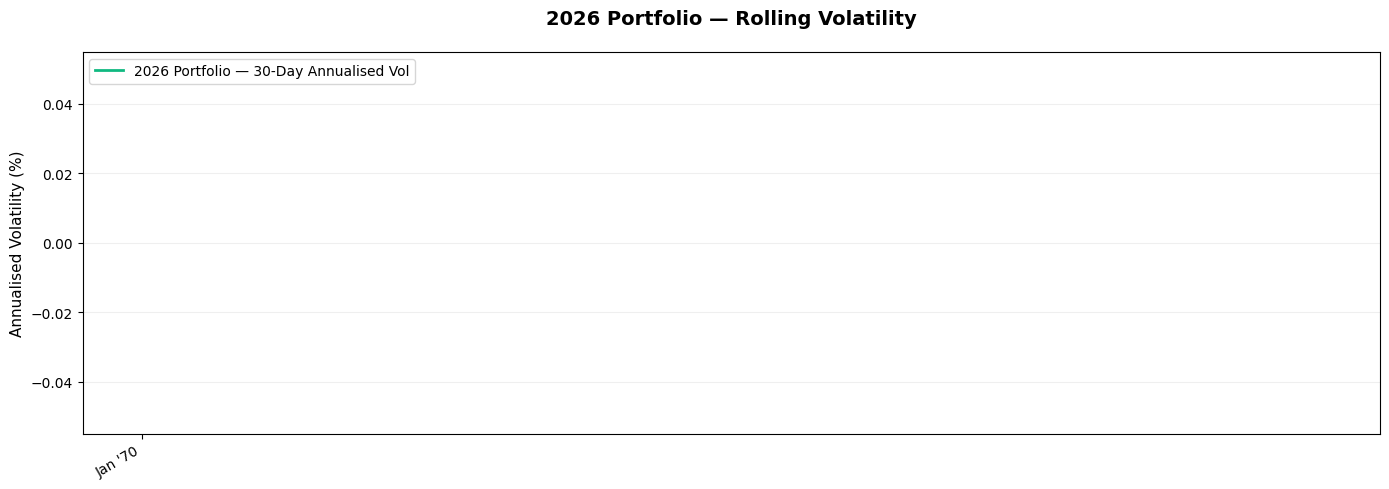

In [5]:
if has_trades:
    rolling_vol = rolling_volatility_from_cumret(twr_series, window=30)
    plt.figure(figsize=(14, 5))
    plt.plot(bt.all_dates, rolling_vol, color='#10b981', linewidth=2,
             label='2026 Portfolio — 30-Day Annualised Vol')
    plt.title('2026 Portfolio — Rolling Volatility',
              fontsize=14, fontweight='bold', pad=20)
    plt.ylabel('Annualised Volatility (%)', fontsize=11)
    plt.grid(axis='y', alpha=0.2)
    plt.legend(loc='upper left', fontsize=10)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
    plt.gcf().autofmt_xdate(rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("No trades — rolling vol unavailable.")


## 4. TWR vs MWR Summary


In [6]:
if has_trades:
    share_ledger = defaultdict(float)
    cost_basis = defaultdict(float)
    for _, t in trades.iterrows():
        share_ledger[t["ticker"]] += t["signed_qty"]
        cost_basis[t["ticker"]] += t["signed_value"]

    CASH_DEPOSITED = 20_000  # 2026 ISA contribution
    total_trade_cost = sum(cost_basis.values())
    estimated_dividends_reinvested = total_trade_cost - CASH_DEPOSITED

    total_value = 0.0
    for t, shares in share_ledger.items():
        px = bt.get_price(t, TODAY)
        if px:
            total_value += shares * px
    mwr_return = (total_value / CASH_DEPOSITED - 1) * 100

    summary_df = pd.DataFrame({
        "Metric": [
            "Time-Weighted Return (TWR)",
            "Money-Weighted Return (MWR)",
            "Net Cash Deposited",
            "Dividends Reinvested (est.)",
            "Current Portfolio Value",
            "Absolute P&L (incl. dividends)",
        ],
        "Value": [
            f"{total_twr:.2f}%",
            f"{mwr_return:.2f}%",
            f"£{CASH_DEPOSITED:,.2f}",
            f"£{estimated_dividends_reinvested:,.2f}",
            f"£{total_value:,.2f}",
            f"£{total_value - CASH_DEPOSITED:,.2f}",
        ],
    })
    display(summary_df)
else:
    print("No trades — TWR/MWR summary unavailable.")


,Metric,Value
0,Time-Weighted Return (TWR),-11.23%
1,Money-Weighted Return (MWR),-57.90%
2,Net Cash Deposited,"£20,000.00"
3,Dividends Reinvested (est.),"£-11,723.15"
4,Current Portfolio Value,"£8,420.75"
5,Absolute P&L (incl. dividends),"£-11,579.25"


## 5. Current Holdings (Share-Based)


In [7]:
if has_trades:
    rows = []
    for t in sorted(share_ledger.keys()):
        shares = share_ledger[t]
        if shares <= 0:
            continue
        px = bt.get_price(t, TODAY) or 0
        val = round(shares * px, 2)
        cost = cost_basis[t]
        mwr = ((val / cost) - 1) * 100 if cost > 0 else 0
        rows.append({
            "Ticker": t,
            "Shares": round(shares, 4),
            "Price (£)": round(px, 2),
            "Value (£)": val,
            "Cost (£)": round(cost, 2),
            "P&L (£)": round(val - cost, 2),
            "MWR (%)": round(mwr, 2),
        })
    holdings_df = pd.DataFrame(rows)
    display(holdings_df)
    print(f"Total Value: £{holdings_df['Value (£)'].sum():,.2f}")
    print(f"Total Cost:  £{holdings_df['Cost (£)'].sum():,.2f}")
    print(f"Total P&L:   £{holdings_df['P&L (£)'].sum():,.2f}")
else:
    print("No trades — holdings unavailable.")


,Ticker,Shares,Price (£),Value (£),Cost (£),P&L (£),MWR (%)
0,EMCP,6.3474,66.86,424.39,424.06,0.33,0.08
1,HKOR,0.9598,95.00,91.18,82.00,9.18,11.20
2,HMCH,30.9428,6.04,186.97,179.95,7.02,3.90
3,IBZL,22.6936,24.67,559.91,562.77,-2.86,-0.51
4,IGLT,17.7343,9.88,175.21,174.03,1.18,0.68
5,IMIB,51.9448,25.80,1339.92,1308.75,31.17,2.38
6,ISJP,36.6208,43.19,1581.65,1557.90,23.75,1.52
7,IUKD,66.3299,9.99,662.90,656.10,6.80,1.04
8,LCUK,1.1799,14.95,17.64,15.72,1.92,12.21
9,PRIJ,0.6995,30.05,21.02,20.18,0.84,4.16


Total Value: £8,459.88
Total Cost:  £8,313.22
Total P&L:   £146.66


## 6. Professional Metrics vs Blended Benchmark


In [8]:
if has_trades:
    first_trade_date = bt.start_date
    first_day_trades = trades[trades["trade_date"] == first_trade_date]
    initial_deposits = {}
    for _, t in first_day_trades.iterrows():
        initial_deposits[t["ticker"]] = (
            initial_deposits.get(t["ticker"], 0) + t["signed_value"]
        )
    total_dep = sum(initial_deposits.values()) if initial_deposits else 0
    bench_weights = (
        {t: v / total_dep for t, v in initial_deposits.items()}
        if total_dep > 0 else {}
    )

    blended_bench = bt.build_blended_benchmark_no_rebalance(bench_weights)
    aligned = pd.concat(
        [twr_series.rename("portfolio"),
         blended_bench.rename("benchmark")],
        axis=1, join="inner",
    ).dropna()

    port_daily = (1 + aligned["portfolio"] / 100).pct_change().dropna()
    bench_daily = (1 + aligned["benchmark"] / 100).pct_change().dropna()

    ann_ret_port = (1 + port_daily.mean()) ** 252 - 1
    ann_vol_port = float(port_daily.std() * np.sqrt(252))
    sharpe_port = calculate_sharpe_ratio(ann_ret_port, ann_vol_port)
    ann_ret_bench = (1 + bench_daily.mean()) ** 252 - 1
    ann_vol_bench = float(bench_daily.std() * np.sqrt(252))
    sharpe_bench = calculate_sharpe_ratio(ann_ret_bench, ann_vol_bench)

    mdd_port = calculate_max_drawdown(1 + aligned["portfolio"] / 100)
    mdd_bench = calculate_max_drawdown(1 + aligned["benchmark"] / 100)
    beta = calculate_beta(port_daily, bench_daily)
    te = calculate_tracking_error(port_daily, bench_daily)
    ir = calculate_information_ratio(port_daily, bench_daily)

    def _fmt_pct(x): return f"{x*100:+.2f}%" if pd.notna(x) else "—"
    def _fmt_num(x, nd=2): return f"{x:.{nd}f}" if pd.notna(x) else "—"

    print("=" * 78)
    print("  Professional Metrics — 2026 Portfolio vs Blended Benchmark")
    print("=" * 78)
    print(f"  Risk-free rate (config):          {RISK_FREE_RATE:.2%}")
    print("-" * 78)
    print(f"  {'':30s}  {'Portfolio':>14s}   {'Benchmark':>14s}")
    print(f"  {'TWR final':30s}  "
          f"{_fmt_num(twr_series.iloc[-1]):>13s}%  "
          f"{_fmt_num(blended_bench.iloc[-1]):>13s}%")
    print(f"  {'Annualised return':30s}  {_fmt_pct(ann_ret_port):>14s}   "
          f"{_fmt_pct(ann_ret_bench):>14s}")
    print(f"  {'Annualised volatility':30s}  {_fmt_pct(ann_vol_port):>14s}   "
          f"{_fmt_pct(ann_vol_bench):>14s}")
    print(f"  {'Sharpe ratio':30s}  {_fmt_num(sharpe_port):>14s}   "
          f"{_fmt_num(sharpe_bench):>14s}")
    print(f"  {'Max drawdown':30s}  {_fmt_pct(mdd_port['value']):>14s}   "
          f"{_fmt_pct(mdd_bench['value']):>14s}")
    print(f"  {'Beta (port vs blended)':30s}  {_fmt_num(beta):>14s}")
    print(f"  {'Tracking error (annualised)':30s}  {_fmt_pct(te):>14s}")
    print(f"  {'Information Ratio':30s}  {_fmt_num(ir):>14s}")
    print("=" * 78)
else:
    print("No trades — metrics unavailable.")


  Professional Metrics — 2026 Portfolio vs Blended Benchmark
  Risk-free rate (config):          4.00%
------------------------------------------------------------------------------
                                       Portfolio        Benchmark
  TWR final                              -11.23%           7.44%
  Annualised return                      -77.88%         +161.72%
  Annualised volatility                  +38.30%          +14.48%
  Sharpe ratio                             -2.14            10.89
  Max drawdown                           -15.31%           -1.26%
  Beta (port vs blended)                    1.39
  Tracking error (annualised)            +33.06%
  Information Ratio                        -7.47
